In [18]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
from copy import deepcopy

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import matplotlib.pyplot as plt
import matplotlib

# GENERAL PLOT OPTIONS
# GENERAL PLOT OPTIONS
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
matplotlib.rcParams['mathtext.rm'] = 'Bitstream Vera Sans'
matplotlib.rcParams['mathtext.it'] = 'Bitstream Vera Sans:italic'
matplotlib.rcParams['mathtext.bf'] = 'Bitstream Vera Sans:bold'
matplotlib.rcParams['xtick.bottom'] = True
matplotlib.rcParams['xtick.labelsize'] = 18
matplotlib.rcParams['xtick.top'] = False
matplotlib.rcParams['ytick.right'] = False
matplotlib.rcParams['ytick.labelsize'] = 18
matplotlib.rcParams['ytick.major.size'] = 6
matplotlib.rcParams['ytick.major.width'] = 1.2
matplotlib.rcParams['ytick.minor.size'] = 3
matplotlib.rcParams['ytick.minor.width'] = 0.8
matplotlib.rcParams['axes.edgecolor'] = 'black'
matplotlib.rcParams['axes.linewidth'] = '1.0'
matplotlib.rcParams['axes.labelsize'] = 18
matplotlib.rcParams['axes.titlesize'] = 24
matplotlib.rcParams['axes.grid'] = True
matplotlib.rcParams['grid.linewidth'] = '0.0'
matplotlib.rcParams['grid.alpha'] = '0.18'
matplotlib.rcParams['grid.color'] = 'lightgray'
matplotlib.rcParams['legend.labelspacing'] = 0.77
matplotlib.rcParams['legend.fontsize'] = 14
matplotlib.rcParams['legend.title_fontsize'] = 18
matplotlib.rcParams['savefig.bbox'] = 'tight'
matplotlib.rcParams['savefig.dpi'] = 300

columnwidth=246/72.27
textwidth=510/72.27

matplotlib.rcParams['axes.titlesize'] = 10
matplotlib.rcParams['axes.labelsize'] = 10
matplotlib.rcParams['legend.fontsize'] = 10
matplotlib.rcParams['legend.title_fontsize'] = 10
matplotlib.rcParams['xtick.labelsize'] = 10
matplotlib.rcParams['ytick.labelsize'] = 10

from scipy.interpolate import interp1d
from scipy.integrate import quad

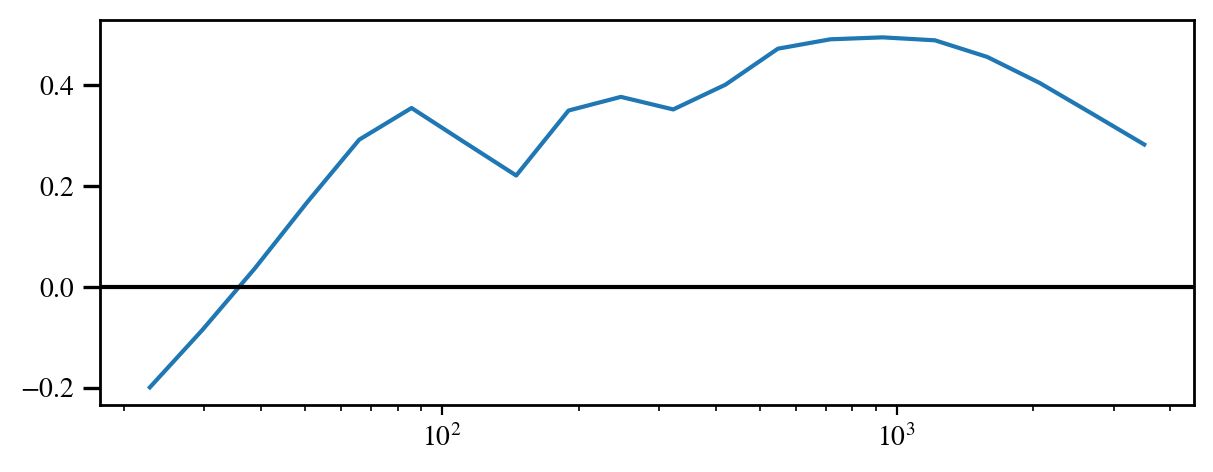

In [20]:

# ccl.gsl_params.LENSING_KERNEL_SPLINE_INTEGRATION = False
# setup cosmology
COSMO = ccl.Cosmology(
    Omega_c=0.26507647072945384,
    Omega_b=0.0495,
    Omega_k=0,
    h=0.6732,
    w0=-1,
    wa=0,
    A_s=2.1/1e9,
    n_s=0.96605,
    m_nu=0.06,
    Neff=3.046,
    mass_split='single',
    transfer_function='boltzmann_camb',
    matter_power_spectrum='camb',
    extra_parameters = {"camb": {"halofit_version": "takahashi",
                                 'AccuracyBoost': 1.0,
                                 'kmax':15,
                                 'dark_energy_model': 'ppf',
                                 'accurate_massive_neutrino_transfer': False,
                                 'k_per_logint': 15,
                                 }}
    )
h=0.6732


#set up lens source sample
srcs_nzs = np.loadtxt('/project/chihway/junzhou/Code-comparison/cocoa/Cocoa/projects/roman_fourier/data/fiducial.nz')
lens_nzs = np.loadtxt('/project/chihway/junzhou/Code-comparison/cocoa/Cocoa/projects/roman_fourier/data/lsst_lens_4cosmolike.nz')

z_srcs = srcs_nzs[:,0]+0.005
srcs_nz = srcs_nzs[:,1:]
z_lens = lens_nzs[:,0]+0.005
lens_nz = lens_nzs[:,1:]

srcs = []
lens = []
nsrcs = 8
nlens = 10
gbias =  [1.09,1.15,1.21,1.27,1.33,1.40,1.46,1.53,1.60,1.67]
ggl_exclude = []

for i in range(nsrcs):
    srcs.append(ccl.WeakLensingTracer(COSMO, dndz=(z_srcs, srcs_nz[:,i]), has_shear=True, n_samples=400))
for i in range(nlens):
    lens.append(ccl.NumberCountsTracer(COSMO, dndz=(z_lens, lens_nz[:,i]), bias=(z_lens,np.ones_like(z_lens)*gbias[i]), has_rsd=False, n_samples=400))


#calculate the power spectrum
ncl= 20
lmin = 20
lmax = 4000
logdl = (np.log(lmax) - np.log(lmin))/ncl
ells = np.zeros(int(ncl))
for i in range(int(ncl)):
    ells[i] = np.exp(np.log(lmin) + (i + 0.5)*logdl)
        
nonlimber = ccl.angular_cl(COSMO, lens[9], lens[9], ells, l_limber=4000)
limber = ccl.angular_cl(COSMO, lens[9], lens[9], ells, l_limber=-1)
r = int((8*9/2 + 8*10 + 10)*20)
l = int((8*9/2 + 8*10 + 9)*20)

import matplotlib.pyplot as plt
plt.figure(figsize=(textwidth,2.5))
plt.plot(ells, (limber-nonlimber)/np.sqrt(np.diag(cov[l:r,:][:,l:r])))
plt.axhline(y=0, xmin=0,xmax=1, color='k', linestyle='-')
plt.xscale('log')

In [8]:
#load covariance matrix and dv from cosmolike
cov_file = '/project/chihway/junzhou/Code-comparison/cocoa/Cocoa/projects/roman_fourier/data/cov_roman_fourier'
mask_file = '/project/chihway/junzhou/Code-comparison/cocoa/Cocoa/projects/roman_fourier/data/roman_Y3.mask'
mask = np.loadtxt(mask_file)[:,1].astype(bool)
cov_raw = np.loadtxt(cov_file)
ncov = int(np.max(cov_raw[:,0]))+1
cov = np.zeros((ncov, ncov))
for i in range(len(cov_raw)):
    ii = int(cov_raw[i, 0])
    jj = int(cov_raw[i, 1])
    element = cov_raw[i,8] + cov_raw[i,9]
    cov[ii,jj] = element
    cov[jj,ii] = element

#dv_cosmolike = np.loadtxt('/project/chihway/junzhou/Code-comparison/cocoa/Cocoa/projects/roman_fourier/chains/roman_setup0_evaluate/roman.modelvector')[:,1]

In [10]:
import importlib
import utils
importlib.reload(utils)

utils.compare(
    dv_ccl,
    dv_cosmolike,
    cov,
    mask,
    'ccl',
    'cosmolike',
    'fourier',
    10,
    8,
    1,
    500,
    20,
    [True, True, True],
    [True, True, True],
    [True, True, True],
    True,
    True,
    True,
    False,
)

ss full chi2 is 0.052
ss DES-masked chi2 is 0.006
gs full chi2 is 0.063
gs DES-masked chi2 is 0.021
gg full chi2 is 0.078
gg DES-masked chi2 is 0.028
3x2pt full chi2 is 0.198
3x2pt DES-masked chi2 is 0.087
